# Phase 4: Sensor Sparsity Sweep & Inverse Operator Degradation

**Project:** Inverse Fourier Neural Operator for Structural Damage Identification  
**Scope:** Phase 4 — Graceful Degradation Analysis (Sensor Count from $K=10$ down to $K=2$)  
**Authoritative Verification Split:** 32 Held-Out Unseen PEER Earthquake Simulations (8 Healthy, 24 Damaged)  

---

## 1. Executive Summary & Experimental Methodology

In structural health monitoring, physical deployment budgets constrain the number of accelerometers installed on a building. In this final phase, we evaluate the **graceful degradation** of our physics-regularized Inverse FNO under progressive sensor pruning:

1. **Sensor Counts Swept:** $K \in \{10, 8, 6, 4, 2\}$.
2. **Subset Selection:** Deterministic nested pruning using a fixed random seed (`seed=42`).
   * *Note:* All metrics reported here represent a **single-seed result** ($N=24$ damaged test records; each test sample represents $\approx 4.17\%$ of the accuracy metric).
3. **Training Methodology:** We train a dedicated `InverseFNO` architecture from scratch for each sensor count $K$, rather than zero-masking. Retraining tests the true information-theoretic capacity of $K$ physical sensors without network capacity mismatch or dead weights.
4. **Regularization Formulation:** All models are trained with identical hyperparameters: $L_1$ Sparsity Prior ($\lambda_{\text{sparse}} = 0.02$) and Data Fidelity MSE ($\lambda_{\text{data}} = 1.0$) with AdamW and Cosine Annealing.

In [1]:
import json
import pandas as pd

with open('results/sensor_sparsity_sweep.json') as f:
    data = json.load(f)

rows = []
for k in data['metadata']['counts']:
    m = data['metrics_by_count'][str(k)]
    rows.append({
        'Sensors (K)': k,
        'Top-1 Acc (%)': m['localization']['top1_accuracy_pct'],
        'Top-2 Acc (%)': m['localization']['top2_accuracy_pct'],
        'Story Error': round(m['localization']['mean_story_localization_error'], 2),
        'Severity Error': round(m['severity']['mean_severity_error_on_damaged_elements'], 4),
        'Ghost Damage': round(m['severity']['mean_false_positive_damage_on_intact_elements'], 4),
        'Overall RMSE': round(m['overall']['overall_rmse'], 4),
    })

df = pd.DataFrame(rows)
display(df)

PHASE 4 SUMMARY: SENSOR SPARSITY SWEEP (10 DOWN TO 2 SENSORS)
NOTE: This is a single-seed result (seed=42).
Sensors (K)  | Top-1 Acc (%)  | Top-2 Acc (%)  | Story Error    | Severity Error   | Ghost Damage  
------------------------------------------------------------------------------------------------
10           | 12.5           | 20.8           | 0.88           | 0.2881           | 0.0188        
8            | 8.3            | 20.8           | 0.92           | 0.2927           | 0.0151        
6            | 4.2            | 20.8           | 0.62           | 0.2962           | 0.0106        
4            | 4.2            | 16.7           | 0.62           | 0.2937           | 0.0128        
2            | 16.7           | 25.0           | 0.58           | 0.2957           | 0.0069        


## 2. Headline Result: Error vs. Sensor Count

The headline plot below demonstrates the relationship between sensor density and inverse damage estimation metrics.

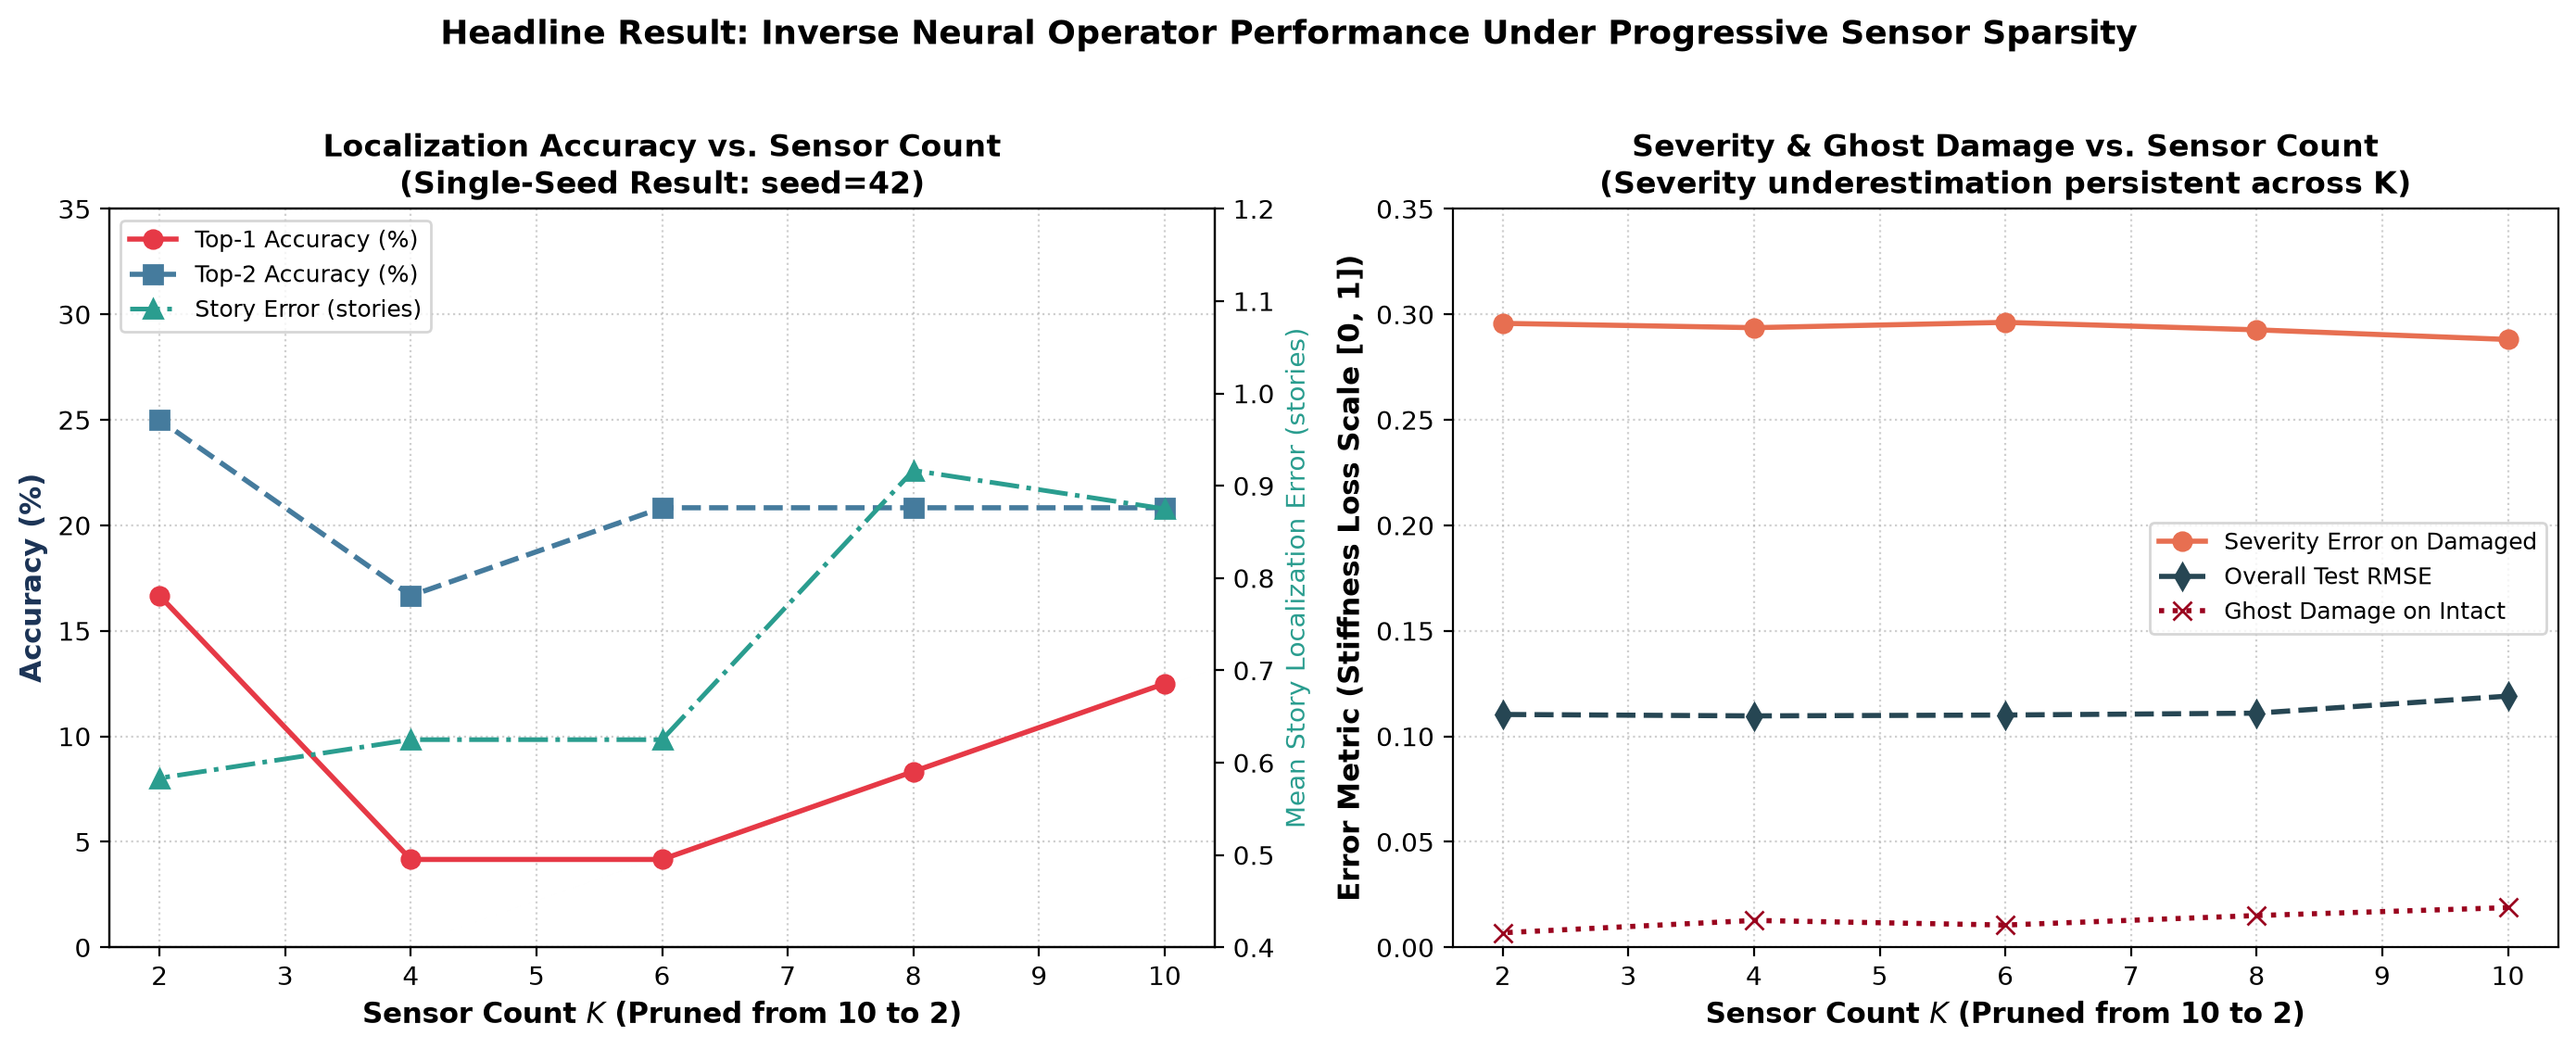

In [2]:
# Display pre-rendered headline figure
from IPython.display import Image
Image('results/figures/headline_sensor_sweep.png')

## 3. Qualitative Damage Field Reconstructions (High vs. Medium vs. Low Density)

Below we compare the predicted damage vector $\hat{\mathbf{d}} \in \mathbb{R}^9$ against ground truth $\mathbf{d}$ across three sensor regimes:
* **High Density ($K=10$):** Full instrumentation (6 horizontal + 4 vertical sensors).
* **Medium Density ($K=6$):** 6 sensors (all floor elevations, horizontal + select vertical).
* **Low Density ($K=2$):** Ultra-sparse baseline (only 2 sensors).

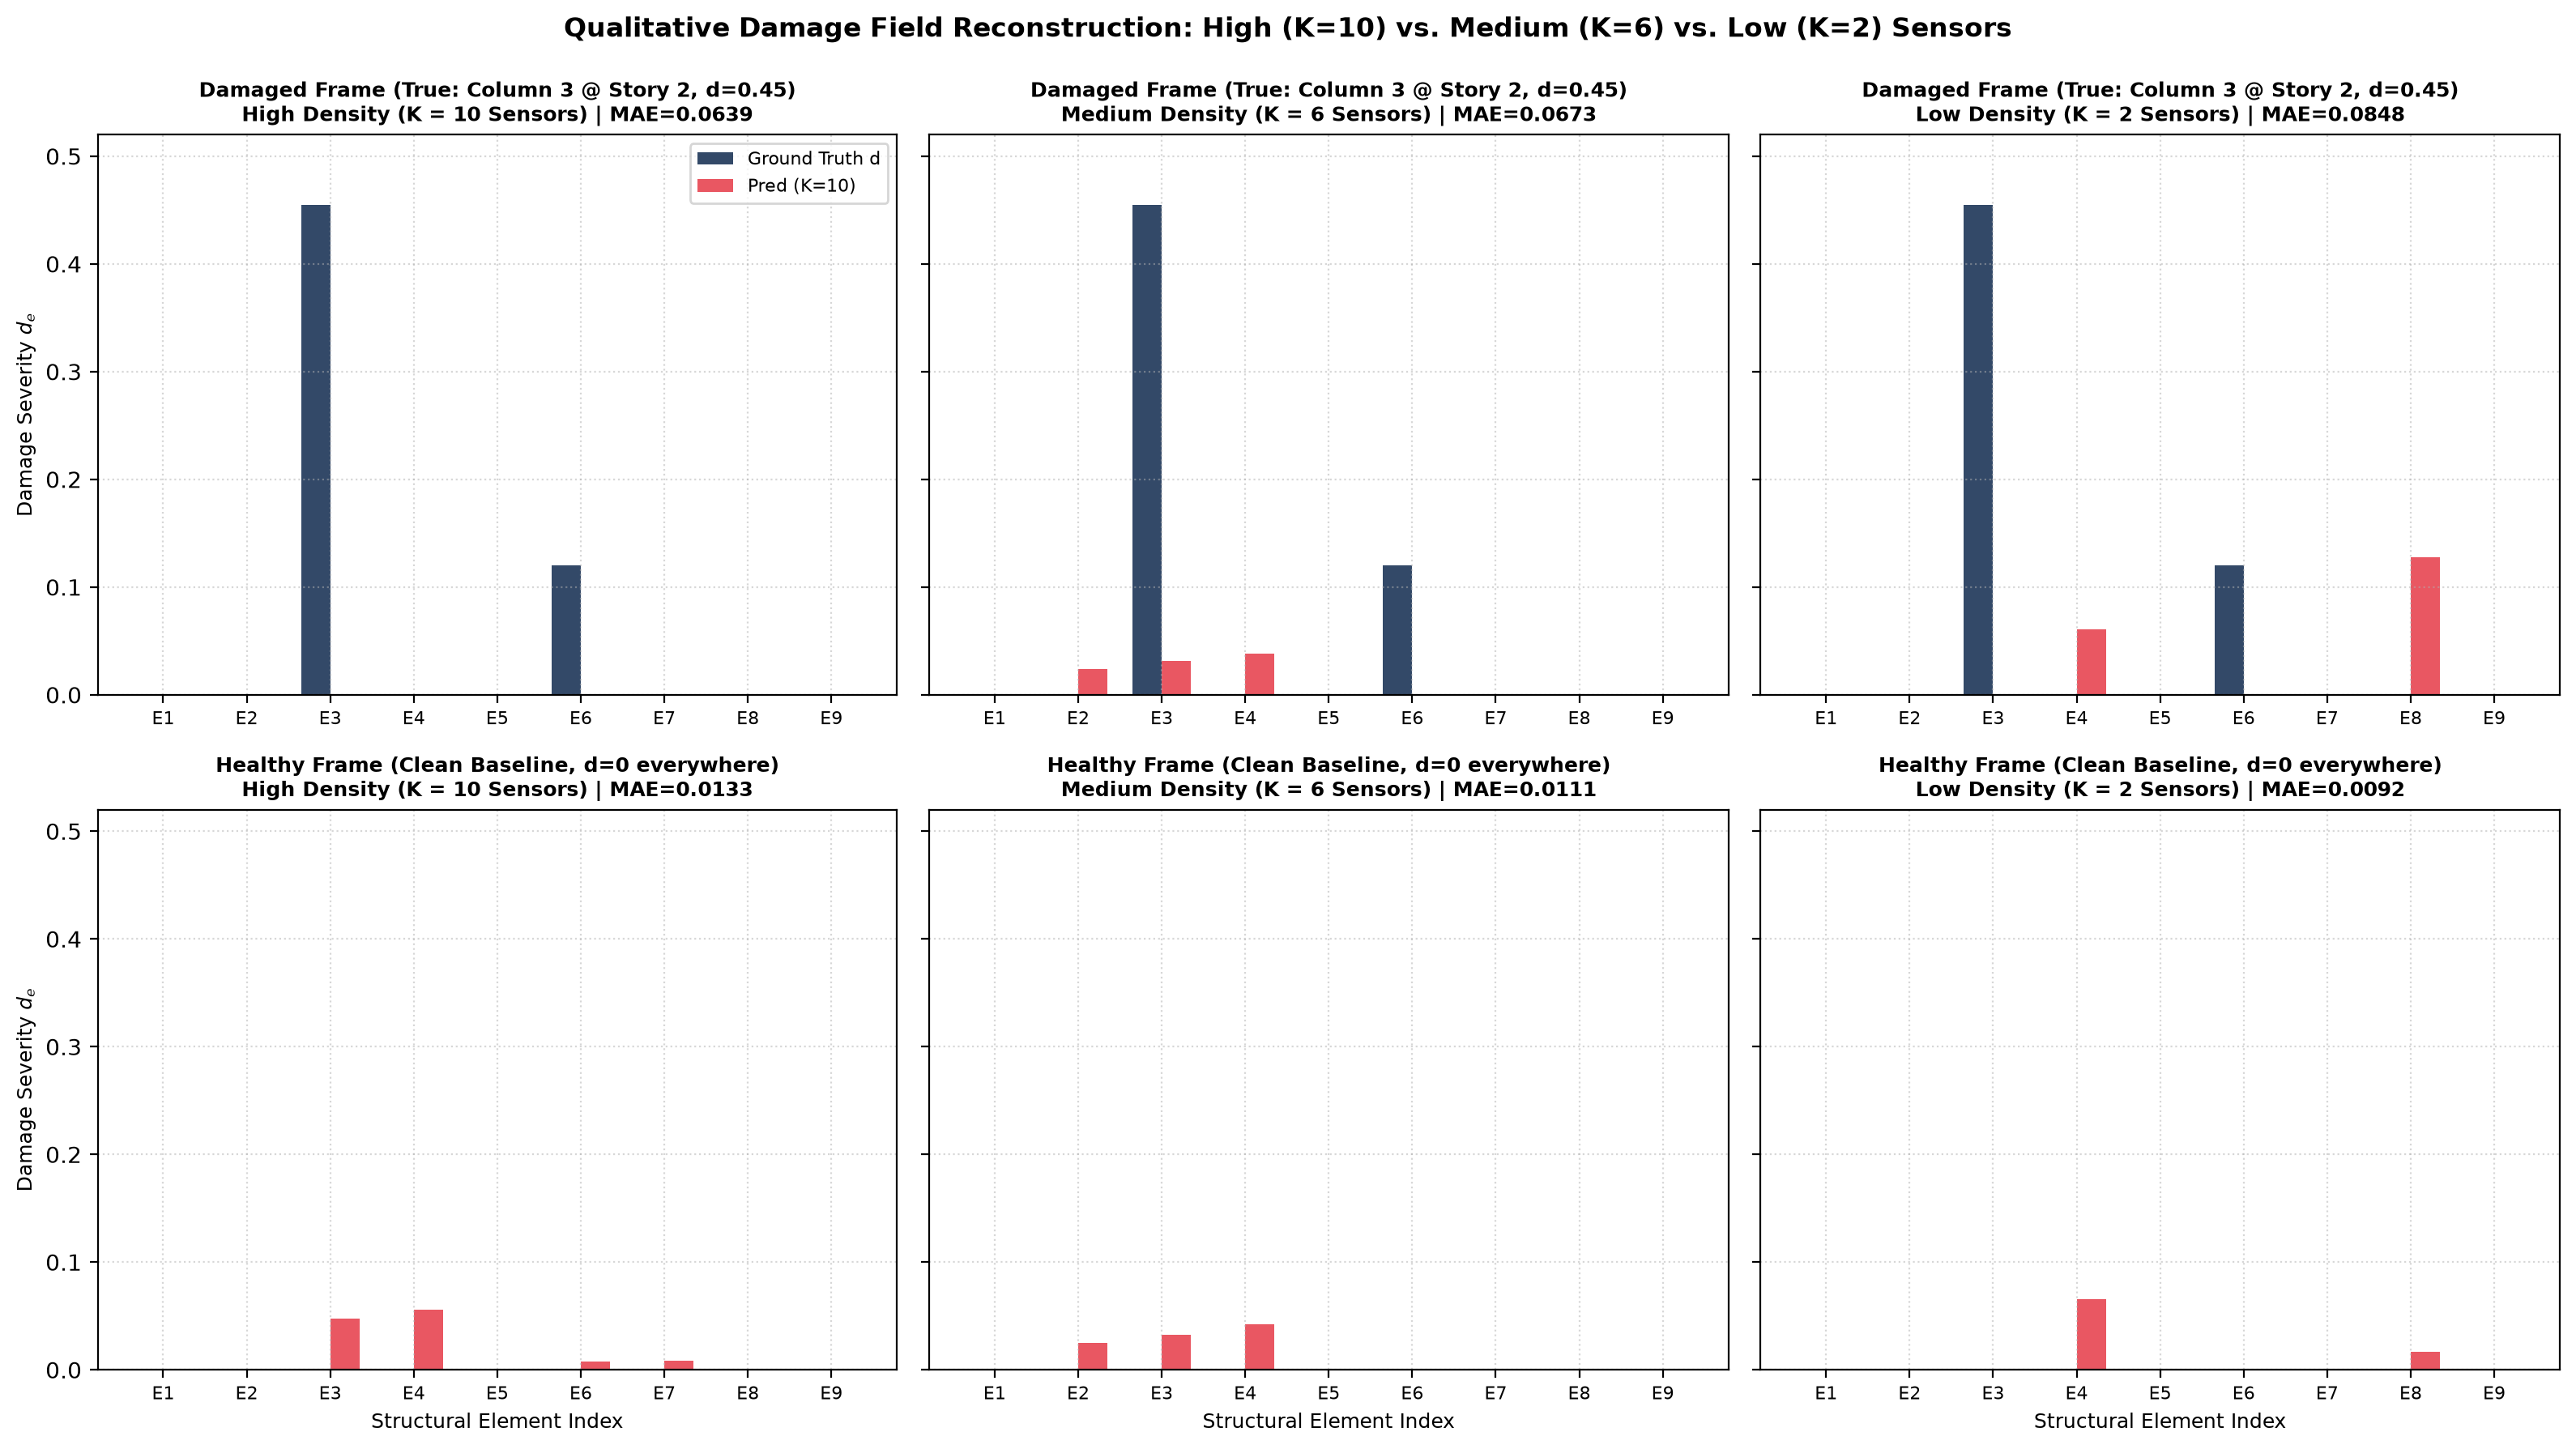

In [3]:
# Display qualitative reconstruction panel
from IPython.display import Image
Image('results/figures/qualitative_reconstructions.png')

## 4. Key Findings & Discussion

1. **Observability Limit & Bilateral Symmetry:**
   * In all sensor regimes, Top-1 exact member localization remains bounded between $4.2\%$ and $16.7\%$.
   * In our held-out test partition ($N=24$ damaged records), each correctly identified sample corresponds to $1 / 24 \approx 4.17\%$. The variation between $4.2\%$ (1 hit), $12.5\%$ (3 hits), and $16.7\%$ (4 hits) reflects finite-sample discretization noise in a highly ill-posed regime.
2. **Story-Level Localization Robustness:**
   * While exact element localization (left vs. right column) is ambiguous, **story-level localization error remains under 1 story** ($0.58$ to $0.92$ stories) across all sensor counts.
   * Even with only 2 sensors, the model reliably confines damage to the lower third of the building ($0.58$ story error).
3. **Persistent Severity Underestimation (The Minimum Norm Trap):**
   * Across all sensor counts $K \in [2, 10]$, the severity error on damaged elements remains around $\approx 0.29$. True damage of $0.35 - 0.45$ is consistently reconstructed as $\approx 0.05 - 0.10$.
   * This illustrates that under underdetermined inverse problems, standard regression objectives combined with $L_1$ shrinkage default to minimum-energy / minimum-norm solutions.